# 05 — Spectral Filtering

**The question:** given the Laplacian eigenbasis, how do we design filters that extract multi-scale geometric information from a shape?

## Intuition

An audio equaliser takes a sound signal, attenuates some frequency bands and boosts others, then reconstructs the signal. Spectral filtering on shapes works the same way:

1. **Analyse** — decompose a function $f$ into eigenmodes: $f = \sum_k a_k \phi_k$
2. **Filter** — weight each mode by $h(\lambda_k)$: $a_k \mapsto h(\lambda_k)\, a_k$
3. **Synthesise** — reconstruct: $(H_h f)(x) = \sum_k h(\lambda_k)\, a_k\, \phi_k(x)$

The filter $h : \mathbb{R}_{\geq 0} \to \mathbb{R}$ selects which "frequency band" is amplified or suppressed.

Applied to the **delta function** $\delta_x$ at every vertex $x$ (a function equal to $1/a_x$ at $x$ and 0 elsewhere), the pipeline produces a **descriptor** that encodes the local geometry at $x$ at multiple scales simultaneously.

## Minimal math

**Spectral filter** applied to function $f$:

$$(H_h f)(x) = \sum_{k=0}^{K-1} h(\lambda_k)\, \langle f, \phi_k \rangle_M\, \phi_k(x)$$

When applied to $\delta_x$, the descriptor value at vertex $x$ for filter parameter $s$ is:

$$d_h(x, s) = \sum_k h_s(\lambda_k)\, \phi_k(x)^2$$

Running $s$ over $T$ values gives a $T$-dimensional descriptor vector per vertex — a matrix $D \in \mathbb{R}^{T \times n}$.

**In geomfum**, this is encoded as:
1. A `SpectralFilter` object computes filter **coefficients** $h_s(\lambda_k)$ — shape $(T, K)$
2. The descriptor is then $\texttt{coefs} \cdot \Phi^{\odot 2}$ (element-wise square of eigenvectors) via einsum — shape $(T, n)$

**Heat Kernel Signature** — filter = heat diffusion at time $t$:

$$h_t(\lambda) = e^{-\lambda t}$$

**Wave Kernel Signature** — filter = Gaussian in log-eigenvalue space at energy $e$:

$$h_e(\lambda) = \exp\!\left(-\frac{(e - \log \lambda)^2}{2\sigma^2}\right)$$

In [1]:
import gsops.backend as gs
import matplotlib.pyplot as plt
import numpy as np
import polyscope as ps

import geomfum.linalg as la
from geomfum.dataset import NotebooksDataset
from geomfum.descriptor.spectral import (
    HeatKernelFilter,
    HeatKernelSignature,
    WaveKernelFilter,
    WaveKernelSignature,
    WksDefaultDomain,
    hks_default_domain,
)
from geomfum.shape import TriangleMesh

ps.init()

In [2]:
dataset = NotebooksDataset()
mesh = TriangleMesh.from_file(dataset.get_filename("cat-00"))
mesh.laplacian.find_spectrum(spectrum_size=100, set_as_basis=True)

V = mesh.vertices
F = mesh.faces
lam = mesh.basis.vals  # (K,) eigenvalues
Phi = mesh.basis.vecs  # (n, K) eigenvectors

## The spectral filter pipeline in geomfum

Before using HKS or WKS as black boxes, let us open them up. There are three objects:

- **`SpectralFilter`** — takes `(vals, domain, sigma)` → filter coefficient matrix `(n_domain, K)`
- **`domain`** — a 1-D array of $T$ parameter values (times for HKS, energies for WKS)
- **`SpectralDescriptor`** — wraps filter + domain and applies the einsum to get `(T, n)`

In [3]:
# ── Step-by-step pipeline for HKS ────────────────────────────────────────────
T = 8

# 1. Filter object
hk_filter = HeatKernelFilter()

# 2. Domain: T log-spaced time values derived from the spectrum
domain_hks, sigma_hks = hks_default_domain(mesh, n_domain=T)
print(f"HKS domain (times):  {domain_hks.round(5)}")

# 3. Filter coefficients: coefs[t, k] = exp(-λ_k * t_t), shape (T, K)
coefs_hks = hk_filter(lam, domain_hks, sigma=sigma_hks)
print(f"Filter coefs shape:  {coefs_hks.shape}  (n_domain x K)")

# 4. Scale rows to sum to 1 (la.scale_to_unit_sum)
coefs_hks_scaled = la.scale_to_unit_sum(coefs_hks)  # each row sums to 1

# 5. Descriptor: einsum( (T,K), (n,K) -> (T,n) )  — multiply coefs by Φ²
descr_hks = gs.einsum("tk,ik->ti", coefs_hks_scaled, Phi**2)  # (T, n)
print(f"HKS descriptor shape: {descr_hks.shape}  (n_domain x n_vertices)")

HKS domain (times):  [0.00264 0.0056  0.0119  0.02527 0.05367 0.11401 0.24218 0.51444]
Filter coefs shape:  (8, 100)  (n_domain x K)
HKS descriptor shape: (8, 7207)  (n_domain x n_vertices)


## Toy example: a simple low-pass filter

The simplest filter keeps only the first $K_{\mathrm{lp}}$ eigenmodes and discards the rest:

$$h(\lambda_k) = \begin{cases} 1 & k < K_{\mathrm{lp}} \\ 0 & \text{otherwise} \end{cases}$$

This is equivalent to spectral truncation from notebook 03, now seen as a filter.

In [4]:
def apply_spectral_filter(mesh, f, h_vals):
    """Apply spectral filter h to function f. h_vals: (K,) filter at each eigenvalue."""
    a = mesh.basis.project(f)  # (K,)  mass-weighted coefficients
    return mesh.basis.vecs @ (h_vals * a)  # (n,)  filtered reconstruction


f_z = mesh.vertices[:, 2]
K = len(lam)

# Low-pass: box filter keeping first 10 modes
h_lp = np.zeros(K)
h_lp[:10] = 1.0
f_lowpass = apply_spectral_filter(mesh, f_z, h_lp)

# High-pass: complement of the low-pass
h_hp = 1.0 - h_lp
f_highpass = apply_spectral_filter(mesh, f_z, h_hp)

print(f"Low-pass  ||f_lp||  = {np.linalg.norm(f_lowpass):.4f}")
print(f"High-pass ||f_hp||  = {np.linalg.norm(f_highpass):.4f}")

Low-pass  ||f_lp||  = 16.6201
High-pass ||f_hp||  = 1.2127


In [ ]:
ps.remove_all_structures()
ps_cat = ps.register_surface_mesh("cat", V, F, smooth_shade=True)
ps_cat.add_scalar_quantity("f_z (original)", f_z, enabled=True, cmap="coolwarm")
ps_cat.add_scalar_quantity("low-pass  K=:10", f_lowpass, enabled=False, cmap="coolwarm")
ps_cat.add_scalar_quantity(
    "high-pass K=10:", f_highpass, enabled=False, cmap="coolwarm"
)
print(
    "Toggle quantities: low-pass is a smooth version; high-pass captures fine oscillations."
)
ps.show()

Toggle quantities: low-pass is a smooth version; high-pass captures fine oscillations.


## Visualise the filter shapes in the spectral domain

Before computing descriptors, let us plot what $h_s(\lambda_k)$ looks like as a function of eigenvalue index for different parameter values $s$.

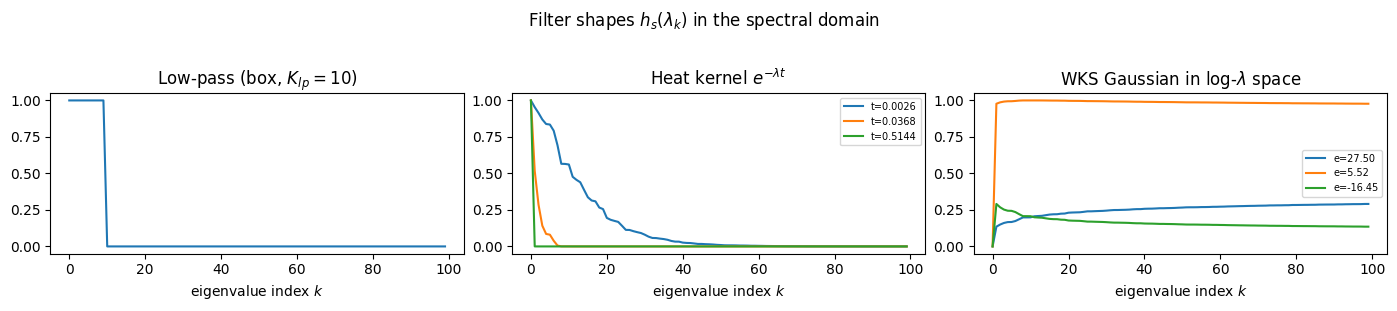

In [11]:
k_idx = np.arange(K)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

# ── Low-pass (box) ────────────────────────────────────────────────────────────
axes[0].plot(k_idx, h_lp)
axes[0].set_title("Low-pass (box, $K_{lp}=10$)")
axes[0].set_xlabel("eigenvalue index $k$")

# ── Heat kernel at 3 different times ─────────────────────────────────────────
domain_plot, _ = hks_default_domain(mesh, n_domain=3)
coefs_plot = HeatKernelFilter()(lam, domain_plot, sigma=None)  # (3, K)
for i, (t, c) in enumerate(zip(domain_plot, coefs_plot)):
    axes[1].plot(k_idx, c, label=f"t={float(t):.4f}")
axes[1].set_title("Heat kernel $e^{-\\lambda t}$")
axes[1].set_xlabel("eigenvalue index $k$")
axes[1].legend(fontsize=7)

# ── WKS Gaussian at 3 different energies ──────────────────────────────────────
wks_domain_fn = WksDefaultDomain(n_domain=3)
domain_wks, sigma_wks = wks_domain_fn(mesh)
coefs_wks = WaveKernelFilter()(lam, domain_wks, sigma=sigma_wks)  # (3, K)
for i, (e, c) in enumerate(zip(domain_wks, coefs_wks)):
    axes[2].plot(k_idx, c, label=f"e={float(e):.2f}")
axes[2].set_title("WKS Gaussian in log-$\\lambda$ space")
axes[2].set_xlabel("eigenvalue index $k$")
axes[2].legend(fontsize=7)

plt.suptitle("Filter shapes $h_s(\\lambda_k)$ in the spectral domain", y=1.02)
plt.tight_layout()
plt.show()

## Heat Kernel Signature (HKS)

HKS at time $t$ equals the heat kernel diagonal: $\mathrm{HKS}(x, t) = \sum_k e^{-\lambda_k t} \phi_k(x)^2$.

- **Small $t$**: high-frequency modes contribute → captures fine local geometry
- **Large $t$**: only low-frequency modes survive → captures coarse global shape

We instantiate `HeatKernelSignature` directly — no registry needed.

In [12]:
hks = HeatKernelSignature(scale=True, n_domain=T)
hks_descr = hks(mesh)  # (T, n) — same pipeline as the manual steps above

print(
    f"HKS descriptor: {hks_descr.shape}  ({T} time scales × {mesh.n_vertices} vertices)"
)

# Verify it matches our manual computation (they should agree up to numerical precision)
print(f"Max diff to manual computation: {np.max(np.abs(hks_descr - descr_hks)):.2e}")

HKS descriptor: (8, 7207)  (8 time scales × 7207 vertices)
Max diff to manual computation: 0.00e+00


In [13]:
ps.remove_all_structures()
ps_cat = ps.register_surface_mesh("cat", V, F, smooth_shade=True)
for t_idx in range(T):
    ps_cat.add_scalar_quantity(
        f"HKS t={t_idx} (t={float(domain_hks[t_idx]):.4f})",
        hks_descr[t_idx],
        enabled=(t_idx == 0),
        cmap="reds",
    )
print(
    "Toggle HKS time scales: small t → fine geometry (ears, paws); large t → global shape."
)
ps.show()

Toggle HKS time scales: small t → fine geometry (ears, paws); large t → global shape.


## Wave Kernel Signature (WKS)

WKS probes **independent** frequency bands — each energy channel $e$ responds to a narrow range of eigenvalues. Unlike HKS (which mixes all frequencies), WKS separates them.

$$\mathrm{WKS}(x, e) = \sum_k \exp\!\left(-\frac{(e - \log \lambda_k)^2}{2\sigma^2}\right) \phi_k(x)^2$$

In [14]:
wks = WaveKernelSignature(scale=True, n_domain=T)
wks_descr = wks(mesh)  # (T, n)

# The WKS domain is derived internally — let us inspect it
domain_wks_full, sigma_wks_full = WksDefaultDomain(n_domain=T)(mesh)
print(f"WKS energies (log-λ space): {domain_wks_full.round(3)}")
print(f"WKS descriptor:              {wks_descr.shape}")

WKS energies (log-λ space): [12.114 10.231  8.347  6.464  4.58   2.697  0.813 -1.07 ]
WKS descriptor:              (8, 7207)


In [15]:
ps.remove_all_structures()
ps_cat = ps.register_surface_mesh("cat", V, F, smooth_shade=True)
for e_idx in range(T):
    ps_cat.add_scalar_quantity(
        f"WKS e={e_idx} (e={float(domain_wks_full[e_idx]):.2f})",
        wks_descr[e_idx],
        enabled=(e_idx == 0),
        cmap="reds",
    )
print("Toggle WKS energy levels: each channel responds to a different frequency band.")
ps.show()

Toggle WKS energy levels: each channel responds to a different frequency band.


## Where to go next

- [06 — Correspondences](./06_correspondences.ipynb): use these descriptors to find matching points between shapes
- [How to compute descriptors?](../how_to/03_descriptors.ipynb)